In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
import json

# Initialize Groq LLM
llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

# Define the expected JSON structure
parser = JsonOutputParser(pydantic_object={
    "type": "object",
    "properties": {
        "name": {"type": "string"},
        "price": {"type": "number"},
        "features": {
            "type": "array",
            "items": {"type": "string"}
        }
    }
})

# Create a simple prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", """Extract product details into JSON with this structure:
        {{
            "name": "product name here",
            "price": number_here_without_currency_symbol,
            "features": ["feature1", "feature2", "feature3"]
        }}"""),
    ("user", "{input}")
])

# Create the chain that guarantees JSON output
chain = prompt | llm | parser

def parse_product(description: str) -> dict:
    result = chain.invoke({"input": description})
    print(json.dumps(result, indent=2))


# Example usage
description = """The Kees Van Der Westen Speedster is a high-end, single-group espresso machine known for its precision, performance,
and industrial design. Handcrafted in the Netherlands, it features dual boilers for brewing and steaming, PID temperature control for
consistency, and a unique pre-infusion system to enhance flavor extraction. Designed for enthusiasts and professionals, it offers
customizable aesthetics, exceptional thermal stability, and intuitive operation via a lever system. The pricing is approximatelyt $14,499
depending on the retailer and customization options."""

parse_product(description)



APIConnectionError: Connection error.

In [8]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="deepseek-r1-distill-llama-70b")
print(llm.invoke("What is the capital of France?").content)

APIConnectionError: Connection error.

In [4]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/var/folders/w4/92z280zx5ms3x2bzmkk6s2hh0000gp/T/ipykernel_85753/156554669.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [5]:
search_tool.invoke("What is the capital of France?")

[{'title': 'List of capitals of France - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
  'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] - Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n- Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] - Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly "National Constituent Assembly (France)") followed the King to Paris soon afterward; Versailles lost its role of capital city.',
  'score': 0.8993429},
 {'title': 'Paris facts: the capita

In [6]:
my_code = """
x=10
y=x+10
print(y)
"""

In [8]:
from langchain_experimental.utilities import PythonREPL
repl=PythonREPL()
repl.run(my_code)


'20\n'

In [9]:
repl.invoke(my_code)

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [10]:
from typing import Annotated

In [11]:
from langchain_core.tools import tool

In [12]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""

    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [10]:
members=["researcher","coder"]

In [11]:
members

['researcher', 'coder']

In [12]:
options = members+["FINISH"]

In [13]:
options

['researcher', 'coder', 'FINISH']

In [14]:
from typing import Literal
from typing_extensions import TypedDict

## There is no routing logic
### it is simply going to return the next candidate(next_agent)
### this next is containig the next candidate name

In [4]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [5]:
from langgraph.graph import MessagesState,StateGraph,START, END

#### this is a messagesstate which we are loading from the langgraph(inbuilt message state)

In [6]:
class State(MessagesState):
    next:str

##### this is how my state will be looking like

In [7]:
class State(MessagesState):
    next:str
state={"messages": ["hi"], "next": "research_agent"}

In [15]:
system_prompt = f"""
You are a supervisor, tasked with managing a conversation between the following workers: {members}.
Given the following user request, respond with the worker to act next.
Each worker will perform a task and respond with their results and status.
When finished, respond with FINISH.
"""

In [16]:
print(system_prompt)


You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder'].
Given the following user request, respond with the worker to act next.
Each worker will perform a task and respond with their results and status.
When finished, respond with FINISH.



In [17]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [18]:
messages

[{'role': 'system',
  'content': "\nYou are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder'].\nGiven the following user request, respond with the worker to act next.\nEach worker will perform a task and respond with their results and status.\nWhen finished, respond with FINISH.\n"},
 'hi']

In [19]:
llm_with_structure_output=llm.with_structured_output(Router)

In [ ]:
llm_with_structure_output.invoke(messages)

#### This is my all three agents

In [20]:
#### This is my all three agents
from langgraph.types import Command

In [21]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]:

    messages = [{"role": "system", "content": system_prompt},] + state["messages"]

    llm_with_structure_output=llm.with_structured_output(Router)

    response=llm_with_structure_output.invoke(messages)

    #this is my response {'next': 'researcher'}

    #this is my next worker agent
    goto=response["next"]

    print("**********BELOW IS MY GOTO***************")

    print(goto)

    if goto == "FINISH":
        goto=END

    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}

    return Command(goto=goto, update={"next":goto})

In [22]:
from langgraph.prebuilt import create_react_agent

In [23]:
from langchain_core.messages import AIMessage, HumanMessage

In [24]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:

    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")

    result=research_agent.invoke(state)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )


In [25]:
def coder_agent(state:State)->Command[Literal['supervisor']]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

#### this is my orchestration flow with langgraph

In [26]:
graph=StateGraph(State)

In [27]:
graph.add_node("supervisor", supervisor_agent)

In [28]:
graph.add_node("researcher", research_agent)

In [29]:
graph.add_node("coder", coder_agent)

In [30]:
graph.add_edge(START, "supervisor")

In [31]:
app=graph.compile()

In [32]:
from IPython.display import display,Image

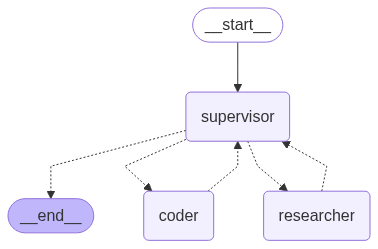

Bad pipe message: %s [b'\xdf\x8a\xbf(\xc6z\xbb\xcc\xdb\xb9!\x96,~H\xbe\xbd\xb8\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07\xc0\x08\xc0\t\xc0\n\xc0\x0b\xc0\x0c\xc0', b'\x0e\xc0\x0f\xc0\x10\xc0\x11\xc0\x12\xc0\x13\xc0']
Bad pipe message: %s [b"\x15\xc0\x16\xc0\x17\xc0\x18\xc0\x19

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

### Persistent setup for zsh (optional)
If the test above succeeds, make the configuration persistent for terminals:

```zsh
# Save your corporate CA to ~/corp-ca.pem (paste PEM content)
cat > ~/corp-ca.pem <<'EOF'
-----BEGIN CERTIFICATE-----
...paste your corporate root CA...
-----END CERTIFICATE-----
EOF

# Create a combined CA bundle using certifi
python - <<'PY'
import certifi, pathlib
corp = pathlib.Path.home()/ 'corp-ca.pem'
combined = pathlib.Path.home()/ 'combined-cacert.pem'
combined.write_bytes(pathlib.Path(certifi.where()).read_bytes() + corp.read_bytes())
print(combined)
PY

# Export vars for future shells
echo 'export SSL_CERT_FILE="$HOME/combined-cacert.pem"' >> ~/.zshrc
echo 'export REQUESTS_CA_BUNDLE="$HOME/combined-cacert.pem"' >> ~/.zshrc
source ~/.zshrc
```

Notes:
- Prefer trusting your corporate CA rather than disabling verification.
- For specific libraries using httpx internally, pass `verify=path_to_combined_bundle` to their client if supported.